In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import os

## Merge the training sets

In [2]:
bjet_train = pd.read_csv('../data/bjet_train.csv')
cjet_train = pd.read_csv('../data/cjet_train.csv')
ljet_train = pd.read_csv('../data/ljet_train.csv')

In [3]:
X_train = pd.concat([bjet_train, cjet_train, ljet_train], ignore_index=True)

In [4]:
y_train = X_train.pop('mc_flavour')

In [5]:
X_train

,PT,ETA,drSvrJet,fdChi2,fdrMin,m,mCor,mCorErr,nTrk,nTrkJet,pt,ptSvrJet,tau,ipChi2Sum
0,20946.177438,2.707440,0.035251,141.475691,0.542914,944.284764,1540.899314,151.282137,3.0,3.0,3945.870645,0.188381,0.156144,107.797163
1,29216.333273,2.556488,0.127721,170.004259,0.506962,1913.931833,3182.253839,297.165250,3.0,2.0,5603.219399,0.191784,0.093517,143.267777
2,22313.861629,2.973624,0.153069,394.557129,0.686985,1527.646610,2132.897943,138.362209,3.0,3.0,10787.480138,0.483443,0.106763,139.803156
3,22709.069322,4.138024,0.280194,1269.791481,2.481682,661.560641,1617.518090,69.681447,2.0,2.0,4665.633712,0.205452,0.626812,608.789159
4,61147.256182,2.354720,0.132560,2345.418371,9.111015,1208.325354,1606.143053,30.367378,3.0,3.0,12417.593659,0.203077,0.785546,14529.534651
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136025,85246.640911,2.143405,0.156284,40.150839,0.722179,440.265722,1096.277125,263.960987,2.0,2.0,4285.152544,0.050268,0.184526,35.381084
136026,85246.640911,2.143405,0.156284,40.150839,0.722179,440.265722,1096.277125,263.960987,2.0,2.0,4285.152544,0.050268,0.184526,35.381084
136027,67625.646646,2.469526,0.047766,273.750167,1.639330,783.667241,1380.632139,145.963540,2.0,2.0,13687.010860,0.202394,0.122312,130.370282
136028,41874.633301,2.541627,0.092675,71.757913,0.138804,4540.500509,5224.960371,870.747585,4.0,3.0,15958.363941,0.381099,0.012623,49.061630


In [6]:
# remapping dictionary for mc_flavour (5 -> 2, 4 -> 1, 0 -> 0) bjet=2, cjet=1, ljet=0
flavour_mapping = {5: 2, 4: 1, 0: 0}
y_train = y_train.map(flavour_mapping)

In [7]:
y_train

0         2
1         2
2         2
3         2
4         2
         ..
136025    0
136026    0
136027    0
136028    0
136029    0
Name: mc_flavour, Length: 136030, dtype: int64

## Exploring the data

In [8]:
# Checking for null values
print("Checking for null values:")
print(X_train.isnull().sum())
print('================')
print(y_train.isnull().sum())

# Are the classes balanced?
print("Are the classes balanced?")
print(f"Size of bjets training set is: {len(bjet_train)}")
print(f"Size of cjets training set is: {len(cjet_train)}")
print(f"Size of ljets training set is: {len(ljet_train)}")

Checking for null values:
PT           0
ETA          0
drSvrJet     0
fdChi2       0
fdrMin       0
m            0
mCor         0
mCorErr      0
nTrk         0
nTrkJet      0
pt           0
ptSvrJet     0
tau          0
ipChi2Sum    0
dtype: int64
0
Are the classes balanced?
Size of bjets training set is: 81852
Size of cjets training set is: 33505
Size of ljets training set is: 20673


In [9]:
def plot_feature_histogram(df_b, df_c, df_l, column_name, bins=50, title=None):
    """
    Plots overlaid histograms for a specific column across three DataFrames (B-jets, C-jets, and Light-jets).
    """
    if column_name not in df_b.columns or column_name not in df_c.columns or column_name not in df_l.columns:
        raise ValueError(f"Column '{column_name}' must exist in all three dataframes.")
        
    plt.figure(figsize=(10, 6))
    
    plt.hist(df_b[column_name].dropna(), bins=bins, color='blue', alpha=0.5, label='B-jets', density=True)
    plt.hist(df_c[column_name].dropna(), bins=bins, color='orange', alpha=0.5, label='C-jets', density=True)
    plt.hist(df_l[column_name].dropna(), bins=bins, color='green', alpha=0.5, label='Light-jets', density=True)
    
    plot_title = title if title else f'Overlaid Distribution of {column_name}'
    plt.title(plot_title, fontsize=14, pad=15)
    plt.xlabel(column_name, fontsize=12)
    plt.ylabel('Normalized Density', fontsize=12)
    
    plt.legend(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

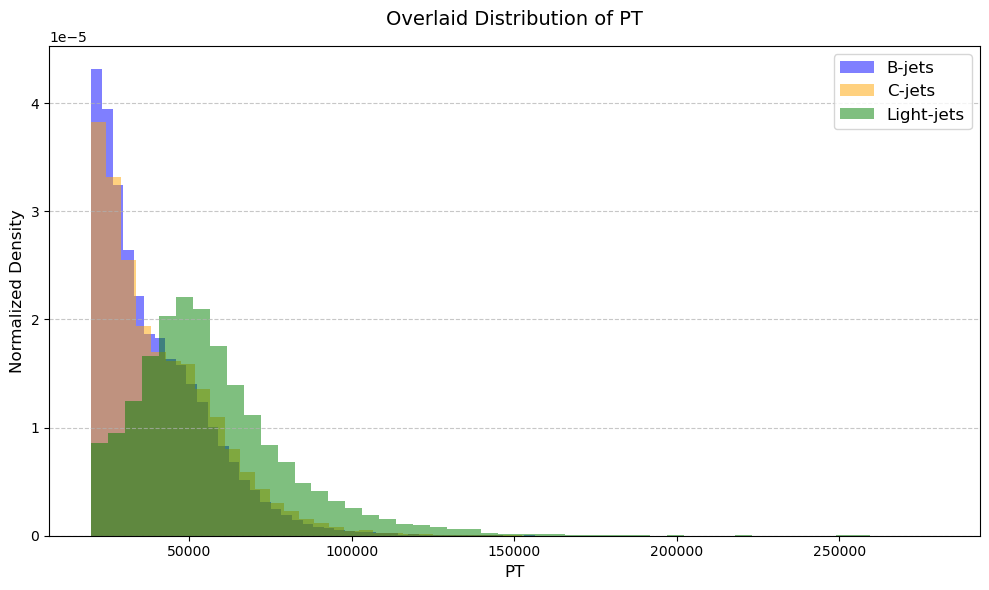

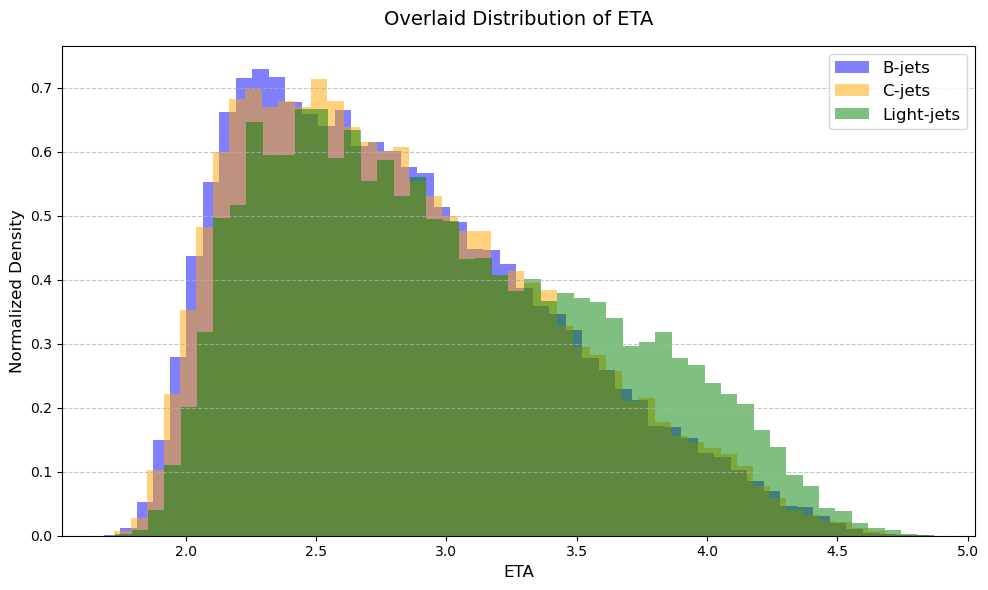

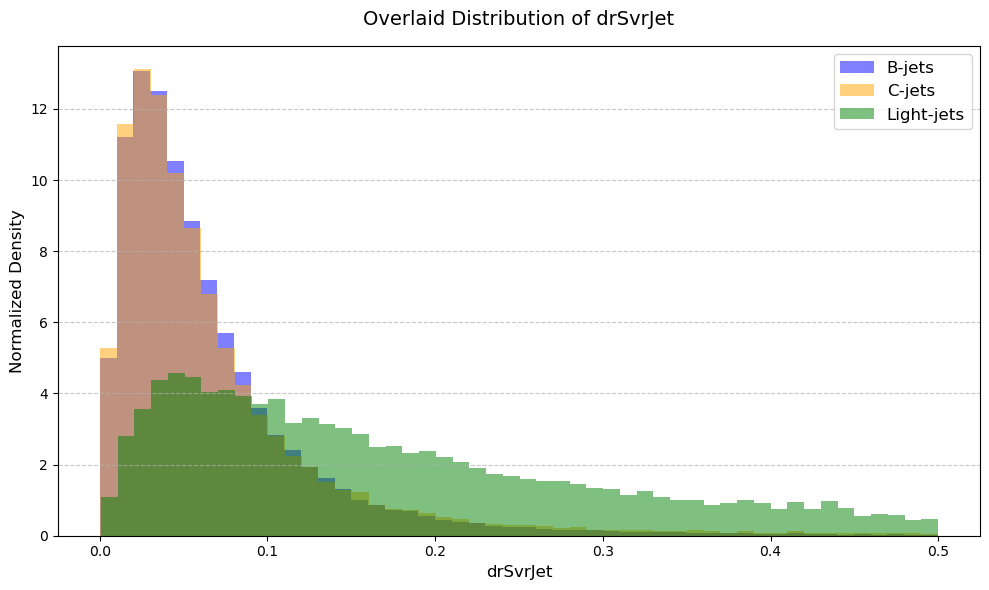

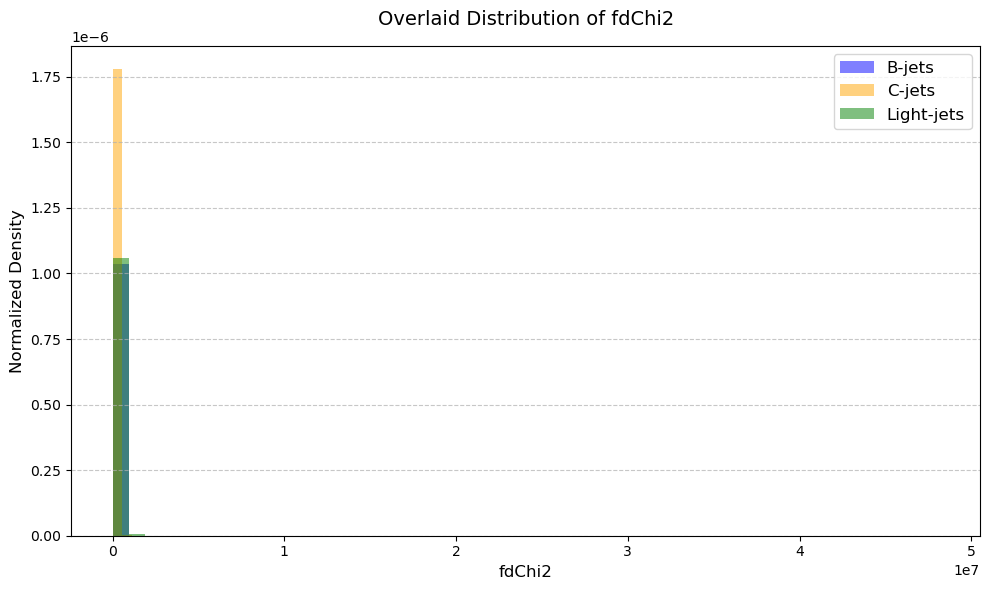

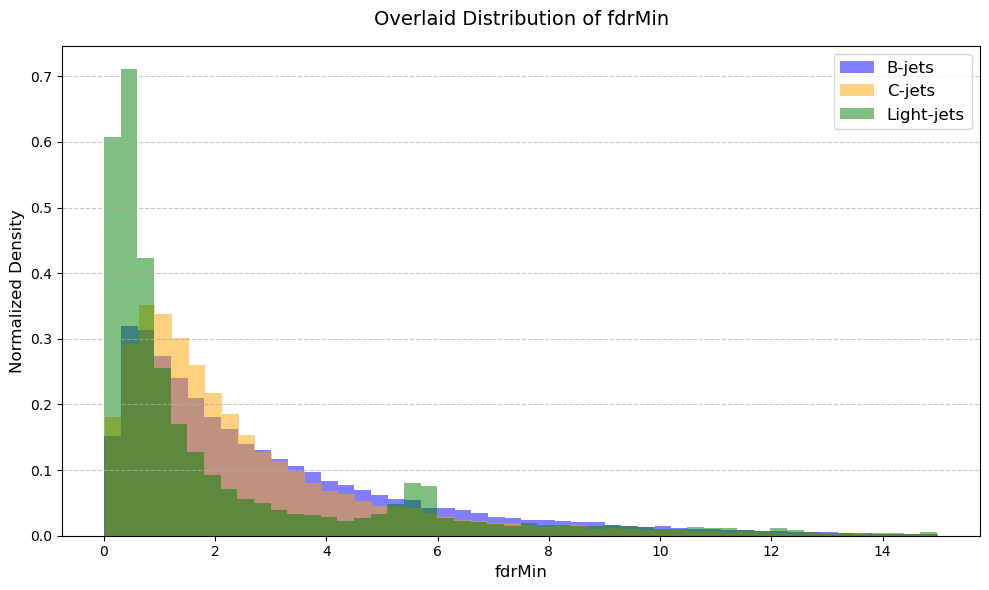

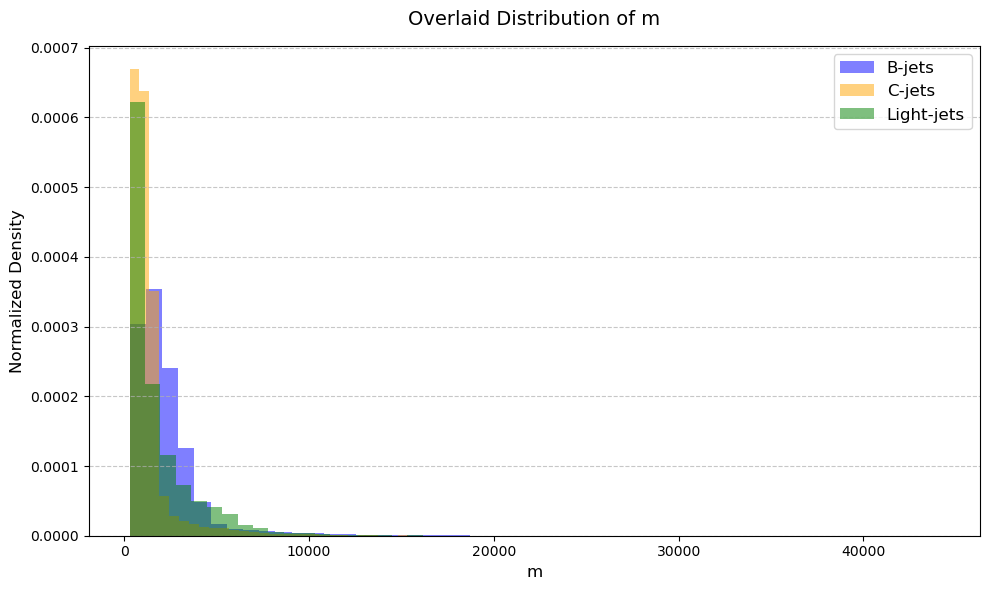

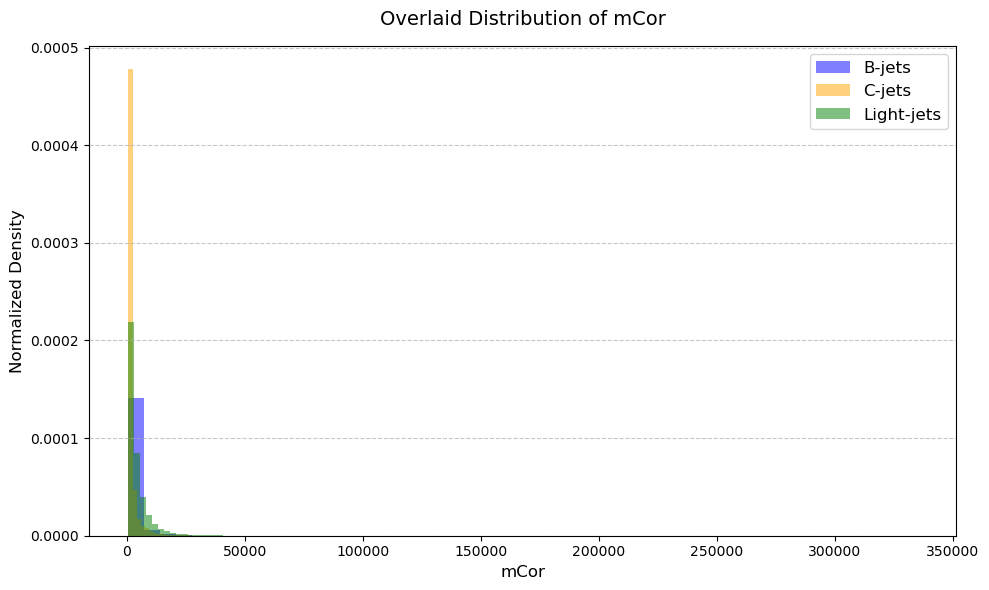

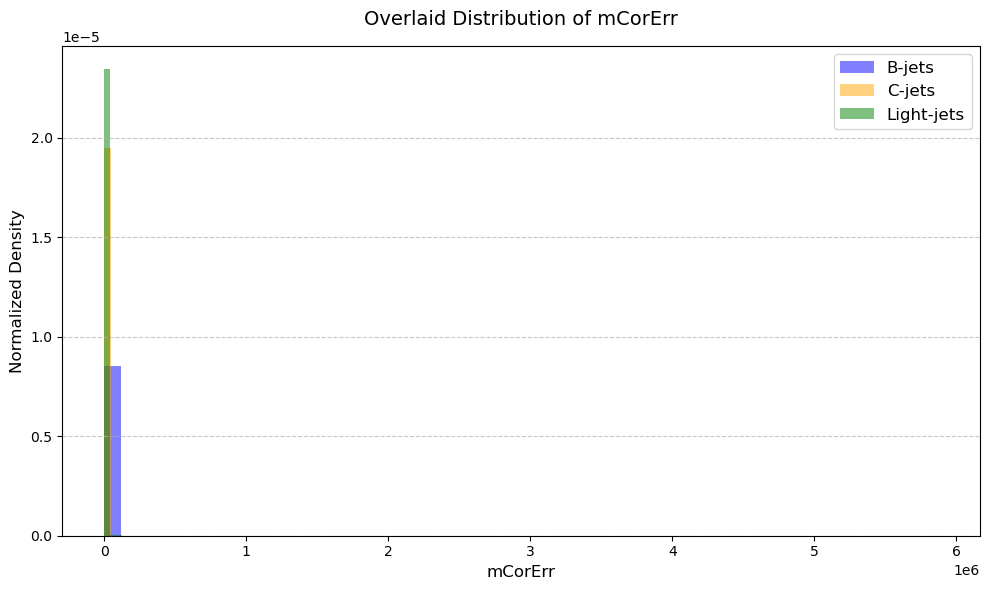

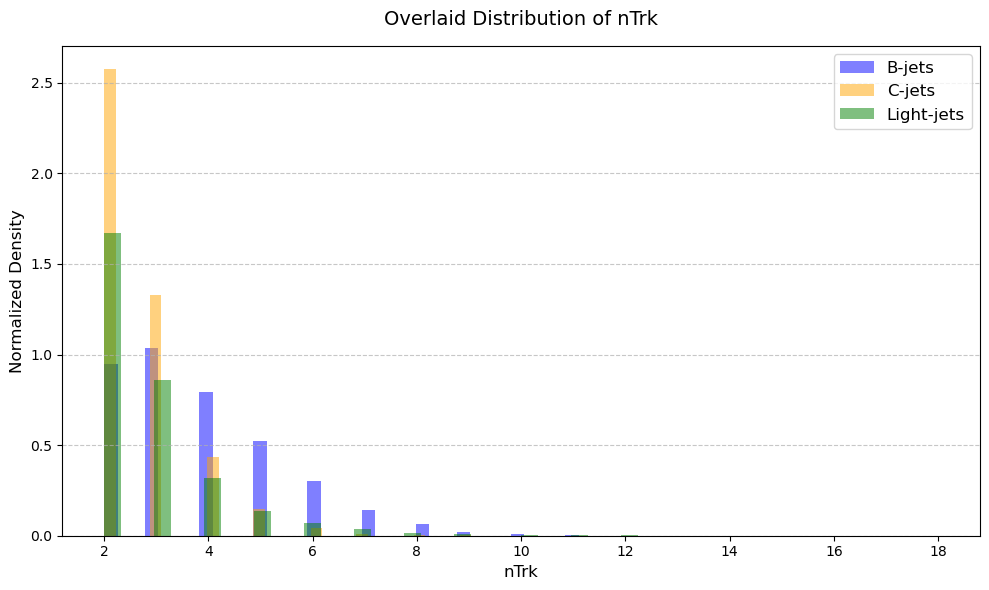

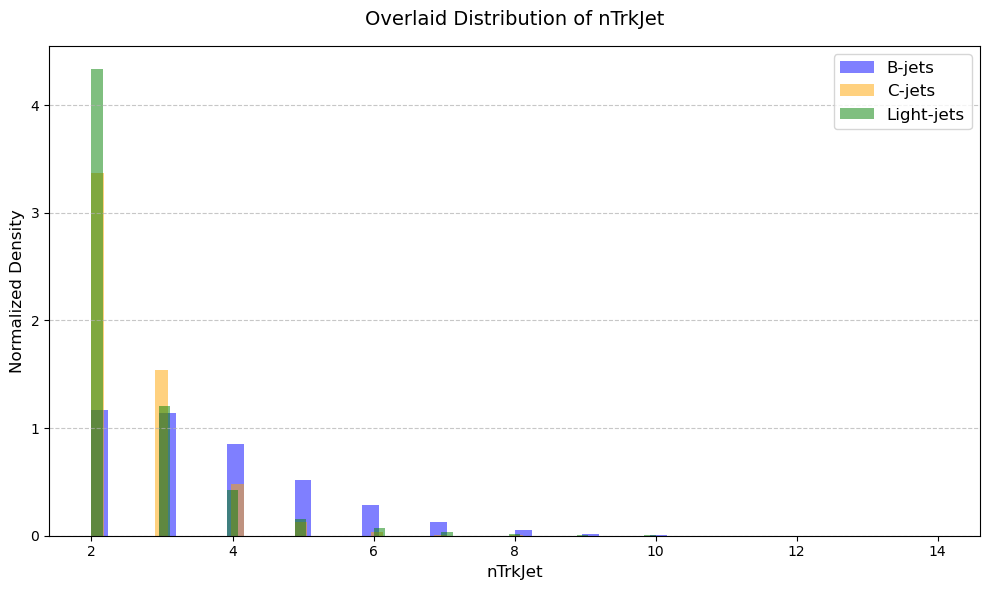

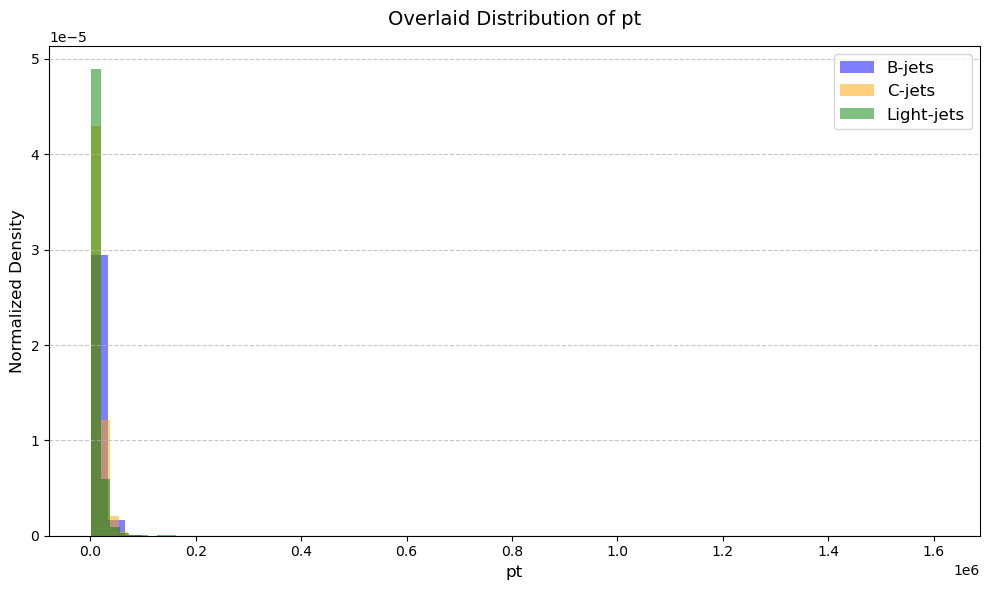

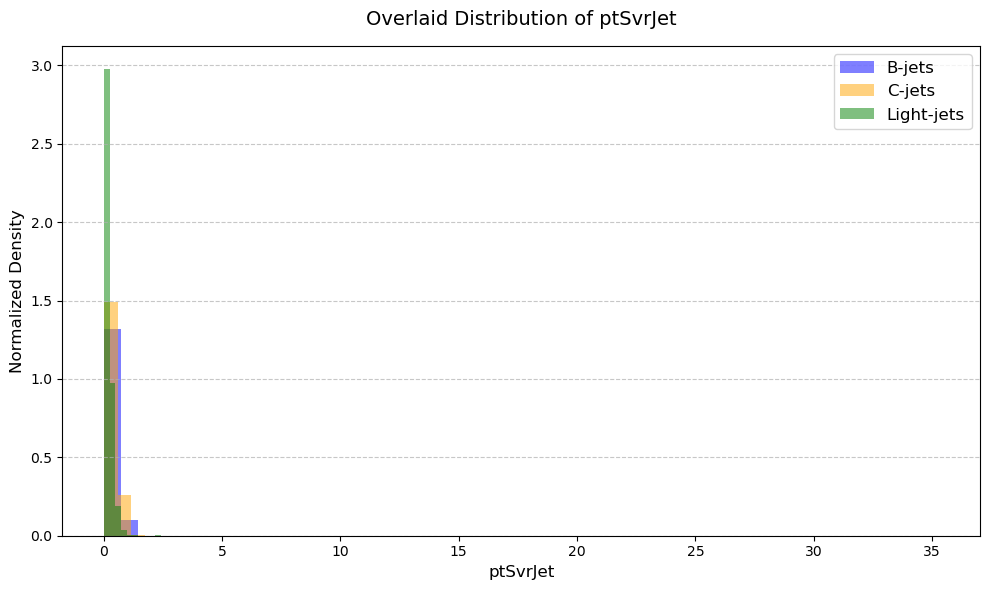

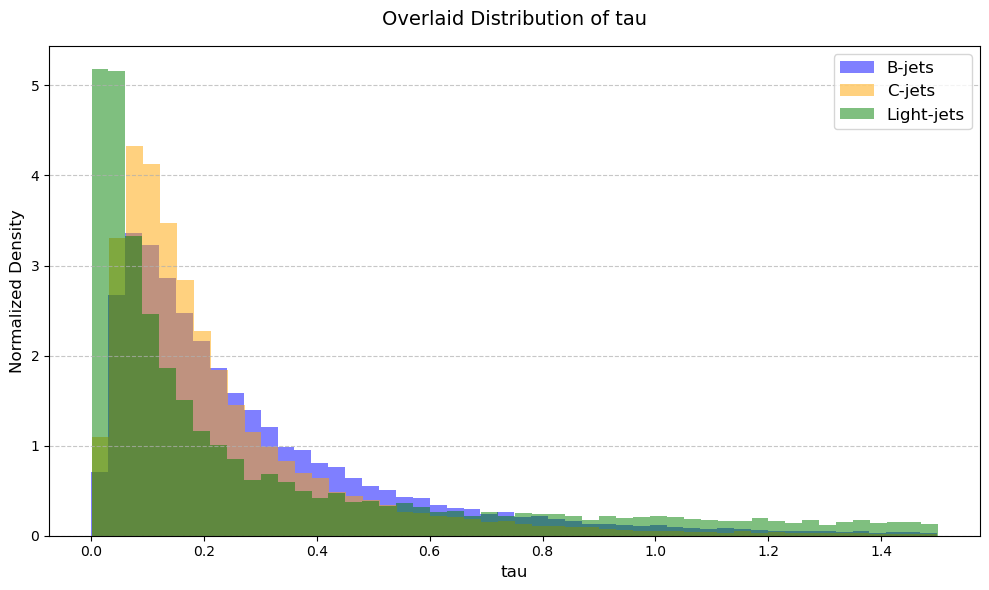

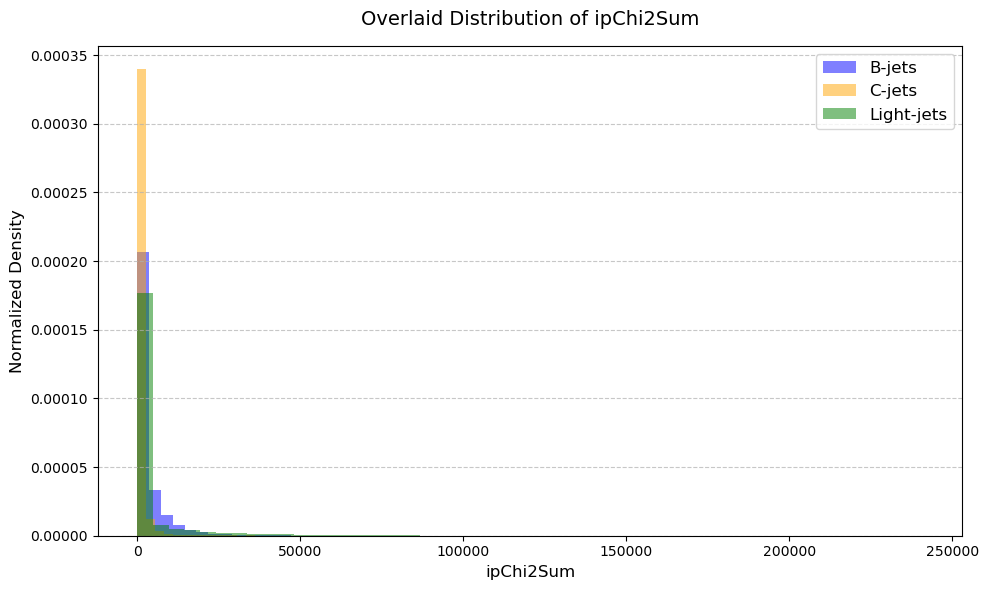

In [10]:
columns_to_plot = X_train.columns

for feature in columns_to_plot:
    plot_feature_histogram(
        df_b=bjet_train, 
        df_c=cjet_train, 
        df_l=ljet_train, 
        column_name=feature
    )

## Split Training Sets

In [11]:
val_fraction  = 0.20   # validation set will have 20% of events, while training set will keep the other 80%
train_fraction = 0.80

# Slipt proportion per class
n_val_bjets  = len(bjet_train)  * val_fraction
n_val_cjets  = len(cjet_train)  * val_fraction
n_val_ljets  = len(ljet_train) * val_fraction

n_train_bjets = len(bjet_train)  - n_val_bjets
n_train_cjets = len(cjet_train)  - n_val_cjets
n_train_ljets = len(ljet_train) - n_val_ljets

n_val_total   = n_val_bjets   + n_val_cjets   + n_val_ljets
n_train_total = n_train_bjets + n_train_cjets + n_train_ljets

print(f"Validation : {n_val_total:>7}  ({n_val_total/len(X_train)*100:.1f}%)")
print(f"  b-jets   : {n_val_bjets:>7}  ({n_val_bjets/n_val_total*100:.1f}%)")
print(f"  c-jets   : {n_val_cjets:>7}  ({n_val_cjets/n_val_total*100:.1f}%)")
print(f"  l-jets   : {n_val_ljets:>7}  ({n_val_ljets/n_val_total*100:.1f}%)")

print(f"\nTraining   : {n_train_total:>7}  ({n_train_total/len(X_train)*100:.1f}%)")
print(f"  b-jets   : {n_train_bjets:>7}  ({n_train_bjets/n_train_total*100:.1f}%)")
print(f"  c-jets   : {n_train_cjets:>7}  ({n_train_cjets/n_train_total*100:.1f}%)")
print(f"  l-jets   : {n_train_ljets:>7}  ({n_train_ljets/n_train_total*100:.1f}%)")

Validation : 27206.0  (20.0%)
  b-jets   : 16370.400000000001  (60.2%)
  c-jets   :  6701.0  (24.6%)
  l-jets   :  4134.6  (15.2%)

Training   : 108824.0  (80.0%)
  b-jets   : 65481.6  (60.2%)
  c-jets   : 26804.0  (24.6%)
  l-jets   : 16538.4  (15.2%)


In [12]:
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, 
    y_train, 
    test_size=0.20,       
    stratify=y_train,     
    random_state=42       
)

## Normalizing the features 

In [13]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_split), 
    columns=X_train_split.columns, 
    index=X_train_split.index
)

X_val_scaled = pd.DataFrame(
    scaler.transform(X_val), 
    columns=X_val.columns, 
    index=X_val.index
)

## Training the model

### We will use a simple logistic regression model first to grasp intuiton

In [14]:
model = sklearn.linear_model.LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train_split)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [15]:
y_pred = model.predict(X_val_scaled)
y_pred_proba = model.predict_proba(X_val_scaled)

In [16]:
accuracy = accuracy_score(y_val, y_pred)
print(f"Overall Validation Accuracy: {accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_val, y_pred))

Overall Validation Accuracy: 71.70%

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.56      0.61      4135
           1       0.60      0.38      0.47      6701
           2       0.75      0.89      0.82     16370

    accuracy                           0.72     27206
   macro avg       0.68      0.61      0.63     27206
weighted avg       0.70      0.72      0.70     27206



### The results are not very accurate. We can use a more powerful model. In HEP it is very common to use BDTs, therefore we can use XGBoost

In [17]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
model = XGBClassifier(n_estimators=500, max_depth=3, learning_rate=0.1)
model.fit(X_train_scaled, y_train_split)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [18]:
y_pred = model.predict(X_val_scaled)
y_pred_proba = model.predict_proba(X_val_scaled)

In [19]:
accuracy = accuracy_score(y_val, y_pred)
print(f"Overall Validation Accuracy: {accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_val, y_pred))

Overall Validation Accuracy: 79.61%

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.72      0.72      4135
           1       0.71      0.63      0.67      6701
           2       0.84      0.88      0.86     16370

    accuracy                           0.80     27206
   macro avg       0.76      0.75      0.75     27206
weighted avg       0.79      0.80      0.79     27206



#### Now we can use the GridSearchCV class to tune the model

In [20]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 1000],
    'max_depth': [3, 7],
    'learning_rate': [0.05, 0.1]
}
grid_search = GridSearchCV(estimator=model, param_grid=param_grid)
grid_search.fit(X_train_split, y_train_split)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1], 'max_depth': [3, 7], 'n_estimators': [100, 1000]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the s

In [21]:
best_params = grid_search.best_params_

In [24]:
model = XGBClassifier(n_estimators=best_params['n_estimators'], max_depth=best_params['max_depth'], learning_rate=best_params['learning_rate'])
model.fit(X_train_scaled, y_train_split)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [25]:
y_pred = model.predict(X_val_scaled)
y_pred_proba = model.predict_proba(X_val_scaled)

accuracy = accuracy_score(y_val, y_pred)
print(f"Overall Validation Accuracy: {accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_val, y_pred))

Overall Validation Accuracy: 83.06%

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81      4135
           1       0.74      0.68      0.71      6701
           2       0.87      0.89      0.88     16370

    accuracy                           0.83     27206
   macro avg       0.80      0.80      0.80     27206
weighted avg       0.83      0.83      0.83     27206



### Applying the model on the competition dataset

In [29]:
X_test = pd.read_csv('../data/competitionData.csv/competitionData.csv')

test_row = X_test.pop('Row')

X_test = pd.DataFrame(
    scaler.transform(X_test), 
    columns=X_test.columns, 
    index=X_test.index
)

In [30]:
test_pred = model.predict(X_test)

In [ ]:
reverse_mapping = {2: 5, 1: 4, 0: 0}

submission = pd.DataFrame({
    'Row': test_row,
    'Prediction': test_pred
})

submission['Prediction'] = submission['Prediction'].map(reverse_mapping)
submission.to_csv('../submissions/submission.csv', index=False)
print(submission.head())
print(submission['Prediction'].value_counts(dropna=False))